# Solución 1: Recomendación de productos por similitud del coseno

Esta libreta documenta y ejecuta la primera solución de extracción de conocimiento del sistema web **Titanium Sport Gym**, siguiendo la metodología **CRISP-DM**.

- **Tipo de solución:** recomendación basada en contenido.
- **Técnica:** TF-IDF y similitud del coseno.
- **Unidad de análisis:** un producto activo del catálogo.
- **Dataset:** `recomendacion.csv`.
- **Salida esperada:** lista top-N de productos similares con puntuación de similitud.


## 1. Comprensión del negocio

Titanium Sport Gym cuenta con una tienda en línea donde se ofrecen suplementos, ropa deportiva y accesorios. El problema de negocio es que el usuario puede consultar un producto sin descubrir otros artículos relacionados, lo que limita la venta cruzada y la navegación personalizada.

El objetivo de esta solución es recomendar productos similares al producto consultado o a los productos del carrito, utilizando los atributos descriptivos del catálogo. El resultado se integra en el sitio web para mostrar secciones como **“También puede interesarte”** y **“Recomendado para ti”**.


## 2. Comprensión de los datos

El dataset se construyó desde la base de datos del proyecto integrador. La consulta SQL extrae productos activos de `core."Products"` y los enriquece con marca y categoría desde `core."Brands"` y `core."Categories"`.

Cada fila representa un producto activo del catálogo y contiene atributos como nombre, categoría, marca, precio, descripción, características, campos de suplemento y campos de ropa.


### 2.1 Importar librerías y definir configuración reproducible


In [16]:
from __future__ import annotations

import json
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

BASE_DIR = Path.cwd()
DATASET_PATH = BASE_DIR / "recomendacion.csv"
ARTIFACTS_DIR = BASE_DIR / "artefactos"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)
plt.style.use("seaborn-v0_8-whitegrid")

configuracion = pd.DataFrame([
    {"elemento": "Directorio de trabajo", "valor": str(BASE_DIR)},
    {"elemento": "Dataset", "valor": str(DATASET_PATH)},
    {"elemento": "Carpeta de artefactos", "valor": str(ARTIFACTS_DIR)},
    {"elemento": "Semilla fija", "valor": RANDOM_STATE},
])
display(configuracion)


,elemento,valor
0,Directorio de trabajo,C:\Users\castr\OneDrive\Escritorio\prueba\entrega_ecbd\solucion_1_recomendacion
1,Dataset,C:\Users\castr\OneDrive\Escritorio\prueba\entrega_ecbd\solucion_1_recomendacion\recome...
2,Carpeta de artefactos,C:\Users\castr\OneDrive\Escritorio\prueba\entrega_ecbd\solucion_1_recomendacion\artefa...
3,Semilla fija,42


### 2.2 Cargar el dataset producido por la extracción


In [17]:
df_raw = pd.read_csv(DATASET_PATH, na_values=["NULL", "null", "", "NaN"])

dimensiones = pd.DataFrame([
    {"etapa": "Dataset cargado", "filas": df_raw.shape[0], "columnas": df_raw.shape[1]}
])
display(dimensiones)
display(df_raw.head())


,etapa,filas,columnas
0,Dataset cargado,160,14


,id_producto,producto,categoryName,brandName,price,description,features,supplementFlavor,supplementPresentation,supplementServings,apparelSize,apparelColor,apparelMaterial,texto_recomendacion
0,1,Proteína Whey Gold Standard 5 lb,Suplementos,Optimum Nutrition,1299.0,Proteína de suero de alta calidad ideal para el desarrollo muscular y recuperación pos...,"[""24 g de proteína por porción"",""Baja en grasas y azúcares"",""Fácil disolución""]",Chocolate,5 lb (2.27 kg),74 servicios,NaN,NaN,NaN,Proteína Whey Gold Standard 5 lb Suplementos Optimum Nutrition 1299.00 Proteína de sue...
1,2,Pre-entreno C4 Original 30 servicios,Suplementos,Cellucor,599.0,"Suplemento pre-entrenamiento diseñado para aumentar la energía, resistencia y enfoque ...","[""Incrementa la energía y concentración"",""Mejora el rendimiento físico""]",Frutas explosivas,195 g,30 servicios,NaN,NaN,NaN,Pre-entreno C4 Original 30 servicios Suplementos Cellucor 599.00 Suplemento pre-entren...
2,3,Creatina Monohidratada 300 g,Suplementos,MuscleTech,449.0,"Suplemento que mejora la fuerza, potencia y rendimiento en entrenamientos de alta inte...","[""Aumenta la fuerza muscular"",""Mejora el rendimiento físico""]",Sin sabor,300 g,60 servicios,NaN,NaN,NaN,Creatina Monohidratada 300 g Suplementos MuscleTech 449.00 Suplemento que mejora la fu...
3,4,Playera Training Dry Fit,Ropa deportiva,Gymshark,988.0,"Playera deportiva diseñada para entrenamientos intensos, con tecnología de secado rápi...","[""Tela transpirable""]",NaN,NaN,NaN,"CH, M, G, XL","Negro, Blanco",Poliéster Dry Fit,Playera Training Dry Fit Ropa deportiva Gymshark 988.00 Playera deportiva diseñada par...
4,5,Short Deportivo Performance,Ropa deportiva,Gymshark,499.0,Short ligero y flexible diseñado para máxima movilidad en entrenamientos de fuerza o c...,"[""Tela ligera y elástica"",""Cintura ajustable""]",NaN,NaN,NaN,"CH, M, G, XL","Negro, Gris",Poliéster + Elastano,Short Deportivo Performance Ropa deportiva Gymshark 499.00 Short ligero y flexible dis...


### 2.3 Diccionario básico y control inicial de calidad


In [18]:
resumen_calidad = pd.DataFrame({
    "columna": df_raw.columns,
    "tipo": [str(df_raw[column].dtype) for column in df_raw.columns],
    "nulos": [int(df_raw[column].isna().sum()) for column in df_raw.columns],
    "porcentaje_nulos": [round(float(df_raw[column].isna().mean() * 100), 2) for column in df_raw.columns],
    "valores_unicos": [int(df_raw[column].nunique(dropna=True)) for column in df_raw.columns],
})
display(resumen_calidad)


,columna,tipo,nulos,porcentaje_nulos,valores_unicos
0,id_producto,int64,0,0.0,160
1,producto,str,0,0.0,160
2,categoryName,str,0,0.0,3
3,brandName,str,0,0.0,7
4,price,float64,0,0.0,43
5,description,str,0,0.0,159
6,features,str,0,0.0,10
7,supplementFlavor,str,104,65.0,21
8,supplementPresentation,str,104,65.0,29
9,supplementServings,str,104,65.0,20


**Interpretación:** los campos específicos de suplemento y ropa pueden contener nulos porque no aplican a todos los productos. Por ejemplo, una playera no tiene sabor o número de servicios, y un suplemento no tiene talla, color o material.


### 2.4 Validar columnas requeridas, duplicados y valores básicos


In [19]:
COLUMNAS_REQUERIDAS = [
    "id_producto",
    "producto",
    "categoryName",
    "brandName",
    "price",
    "description",
    "features",
    "supplementFlavor",
    "supplementPresentation",
    "supplementServings",
    "apparelSize",
    "apparelColor",
    "apparelMaterial",
    "texto_recomendacion",
]

faltantes = [column for column in COLUMNAS_REQUERIDAS if column not in df_raw.columns]
if faltantes:
    raise ValueError(f"Faltan columnas requeridas: {faltantes}")

validacion = pd.DataFrame([
    {"validacion": "Filas originales", "resultado": int(len(df_raw))},
    {"validacion": "Columnas originales", "resultado": int(df_raw.shape[1])},
    {"validacion": "Columnas requeridas faltantes", "resultado": len(faltantes)},
    {"validacion": "Duplicados en id_producto", "resultado": int(df_raw["id_producto"].duplicated().sum())},
    {"validacion": "Textos de recomendacion vacios", "resultado": int(df_raw["texto_recomendacion"].fillna("").str.strip().eq("").sum())},
    {"validacion": "Precios invalidos", "resultado": int(pd.to_numeric(df_raw["price"], errors="coerce").isna().sum())},
])
display(validacion)


,validacion,resultado
0,Filas originales,160
1,Columnas originales,14
2,Columnas requeridas faltantes,0
3,Duplicados en id_producto,0
4,Textos de recomendacion vacios,0
5,Precios invalidos,0


### 2.5 Análisis exploratorio con tablas


In [20]:
resumen_precio = df_raw["price"].describe().to_frame(name="price").reset_index().rename(columns={"index": "estadistico"})
productos_categoria = df_raw["categoryName"].value_counts().rename_axis("categoryName").reset_index(name="productos")
top_marcas = df_raw["brandName"].value_counts().head(10).rename_axis("brandName").reset_index(name="productos")

display(resumen_precio)
display(productos_categoria)
display(top_marcas)


,estadistico,price
0,count,160.00000
1,mean,653.01875
2,std,334.12372
3,min,2.00000
4,25%,444.00000
5,50%,599.00000
6,75%,799.00000
7,max,1699.00000


,categoryName,productos
0,Suplementos,55
1,Ropa deportiva,53
2,Accesorios,52


,brandName,productos
0,Harbinger,52
1,Optimum Nutrition,19
2,Cellucor,19
3,Gymshark,19
4,MuscleTech,17
5,YoungLA,17
6,Adidas,17


### 2.6 Análisis exploratorio con gráficas


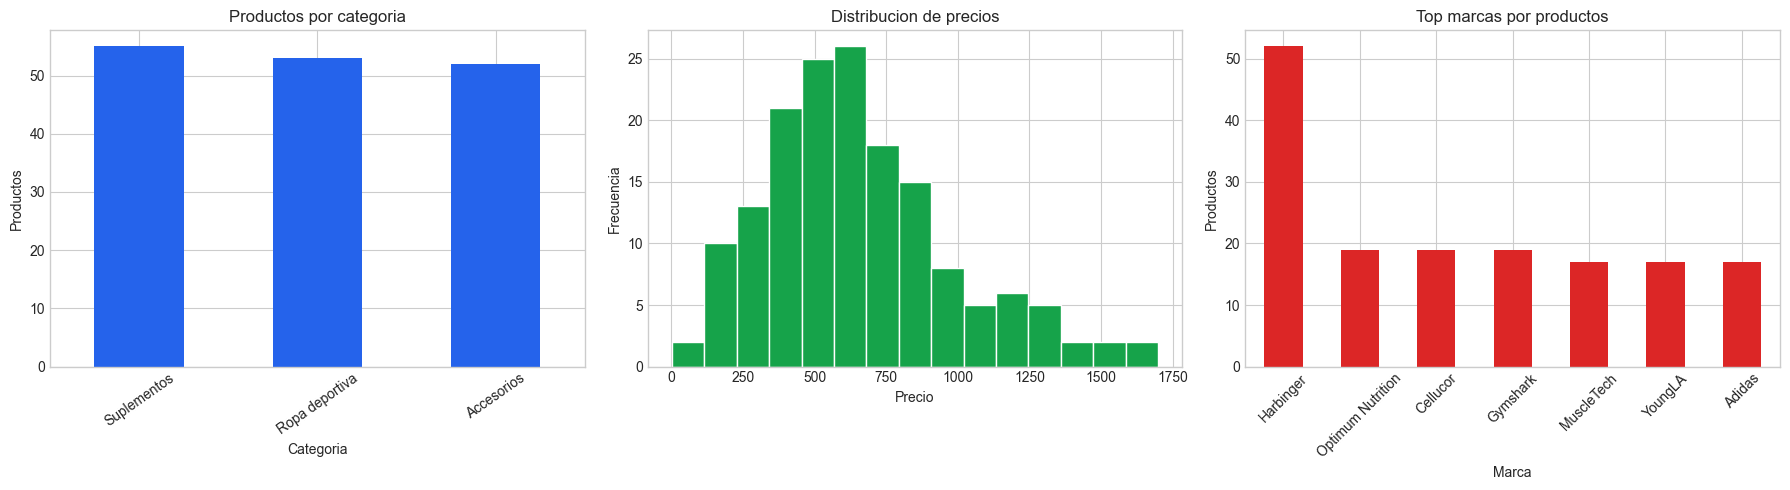

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

productos_categoria.plot(kind="bar", x="categoryName", y="productos", ax=axes[0], legend=False, color="#2563eb")
axes[0].set_title("Productos por categoria")
axes[0].set_xlabel("Categoria")
axes[0].set_ylabel("Productos")
axes[0].tick_params(axis="x", rotation=35)

axes[1].hist(df_raw["price"].astype(float), bins=15, color="#16a34a", edgecolor="white")
axes[1].set_title("Distribucion de precios")
axes[1].set_xlabel("Precio")
axes[1].set_ylabel("Frecuencia")

top_marcas.plot(kind="bar", x="brandName", y="productos", ax=axes[2], legend=False, color="#dc2626")
axes[2].set_title("Top marcas por productos")
axes[2].set_xlabel("Marca")
axes[2].set_ylabel("Productos")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 3. Preparación de los datos

En esta etapa se limpian valores nulos, se convierten tipos de datos y se construye el texto final que será vectorizado. El identificador `id_producto` se conserva solo como referencia, pero no se usa para calcular la similitud.


In [22]:
def texto(valor: object) -> str:
    if pd.isna(valor):
        return ""
    return str(valor).strip()


def repetir(valor: object, veces: int) -> list[str]:
    valor_limpio = texto(valor)
    return [valor_limpio] * veces if valor_limpio else []


def unir_texto(*valores: object) -> str:
    return " ".join(texto(valor) for valor in valores if texto(valor))


def inferir_tipo(row: pd.Series) -> str:
    tiene_suplemento = any(texto(row.get(col)) for col in [
        "supplementFlavor", "supplementPresentation", "supplementServings"
    ])
    tiene_ropa = any(texto(row.get(col)) for col in [
        "apparelSize", "apparelColor", "apparelMaterial"
    ])
    if tiene_suplemento and not tiene_ropa:
        return "Suplementacion"
    if tiene_ropa and not tiene_suplemento:
        return "Ropa"
    return texto(row.get("categoryName")) or "Sin clasificar"


def construir_texto_modelo(row: pd.Series) -> str:
    return unir_texto(
        *repetir(row["producto"], 4),
        *repetir(row["categoryName"], 5),
        *repetir(row["brandName"], 3),
        *repetir(row["grupo_producto"], 2),
        row["description"],
        row["features"],
        *repetir(row["supplementFlavor"], 2),
        *repetir(row["supplementPresentation"], 2),
        *repetir(row["supplementServings"], 2),
        *repetir(row["apparelSize"], 2),
        *repetir(row["apparelColor"], 2),
        *repetir(row["apparelMaterial"], 2),
    )


df = df_raw[COLUMNAS_REQUERIDAS].copy()
df["id_producto"] = df["id_producto"].astype(int)
df["price"] = pd.to_numeric(df["price"], errors="coerce").fillna(0)

columnas_texto = [column for column in COLUMNAS_REQUERIDAS if column not in ["id_producto", "price"]]
df[columnas_texto] = df[columnas_texto].fillna("")
df["grupo_producto"] = df.apply(inferir_tipo, axis=1)
df["texto_modelo"] = df.apply(construir_texto_modelo, axis=1)

dimensiones_preparacion = pd.DataFrame([
    {"etapa": "Antes de preparar", "filas": df_raw.shape[0], "columnas": df_raw.shape[1]},
    {"etapa": "Despues de preparar", "filas": df.shape[0], "columnas": df.shape[1]},
])
display(dimensiones_preparacion)
display(df[["id_producto", "producto", "categoryName", "brandName", "grupo_producto", "texto_modelo"]].head())


,etapa,filas,columnas
0,Antes de preparar,160,14
1,Despues de preparar,160,16


,id_producto,producto,categoryName,brandName,grupo_producto,texto_modelo
0,1,Proteína Whey Gold Standard 5 lb,Suplementos,Optimum Nutrition,Suplementacion,Proteína Whey Gold Standard 5 lb Proteína Whey Gold Standard 5 lb Proteína Whey Gold S...
1,2,Pre-entreno C4 Original 30 servicios,Suplementos,Cellucor,Suplementacion,Pre-entreno C4 Original 30 servicios Pre-entreno C4 Original 30 servicios Pre-entreno ...
2,3,Creatina Monohidratada 300 g,Suplementos,MuscleTech,Suplementacion,Creatina Monohidratada 300 g Creatina Monohidratada 300 g Creatina Monohidratada 300 g...
3,4,Playera Training Dry Fit,Ropa deportiva,Gymshark,Ropa,Playera Training Dry Fit Playera Training Dry Fit Playera Training Dry Fit Playera Tra...
4,5,Short Deportivo Performance,Ropa deportiva,Gymshark,Ropa,Short Deportivo Performance Short Deportivo Performance Short Deportivo Performance Sh...


**Interpretación:** `grupo_producto` es una variable derivada auxiliar para distinguir suplementos y ropa. `texto_modelo` pondera el nombre, la categoría, la marca y los atributos específicos mediante repeticiones controladas. Se excluyen `price`, porque un número no representa semejanza semántica, y `texto_recomendacion`, porque duplica información ya incluida y alteraría los pesos de TF-IDF.


## 4. Modelado

Se utiliza `TfidfVectorizer` para convertir el texto de cada producto en un vector numérico. Se conservan unigramas y bigramas presentes en al menos dos productos (`min_df=2`), ya que los términos exclusivos no pueden contribuir a una coincidencia y sólo aumentarían el ruido. Después se calcula la similitud del coseno: un valor cercano a 1 indica alta similitud y un valor cercano a 0 indica baja similitud.


In [23]:
STOPWORDS_ES = [
    "a", "al", "algo", "ante", "con", "como", "de", "del", "desde", "durante",
    "e", "el", "ella", "en", "entre", "es", "esta", "este", "esto", "ideal",
    "la", "las", "lo", "los", "mas", "mejor", "para", "por", "que", "se",
    "sin", "su", "sus", "un", "una", "unas", "unos", "y"
]

vectorizer = TfidfVectorizer(
    strip_accents="unicode",
    lowercase=True,
    stop_words=STOPWORDS_ES,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    norm="l2",
)

matriz_tfidf = vectorizer.fit_transform(df["texto_modelo"])

resumen_modelado = pd.DataFrame([
    {"metrica": "Productos vectorizados", "valor": matriz_tfidf.shape[0]},
    {"metrica": "Terminos TF-IDF", "valor": matriz_tfidf.shape[1]},
    {"metrica": "N-gramas", "valor": "1 a 2 palabras"},
    {"metrica": "Frecuencia documental mínima", "valor": "2 productos"},
    {"metrica": "Normalización", "valor": "minúsculas, eliminación de acentos y norma L2"},
    {"metrica": "Frecuencia de términos", "valor": "escala logarítmica sublineal"},
])
terminos_muestra = pd.DataFrame({"terminos_ejemplo": vectorizer.get_feature_names_out()[:25]})

display(resumen_modelado)
display(terminos_muestra)

,metrica,valor
0,Productos vectorizados,160
1,Terminos TF-IDF,614
2,N-gramas,1 a 2 palabras
3,Frecuencia documental mínima,2 productos
4,Normalización,"minúsculas, eliminación de acentos y norma L2"
5,Frecuencia de términos,escala logarítmica sublineal


,terminos_ejemplo
0,100
1,100 caps
2,100 capsulas
3,100 servicios
4,180
5,180 180
6,180 30
7,195
8,195 195
9,195 30


In [24]:
matriz_similitud = cosine_similarity(matriz_tfidf)
resumen_similitud = pd.DataFrame([
    {"metrica": "Filas matriz similitud", "valor": matriz_similitud.shape[0]},
    {"metrica": "Columnas matriz similitud", "valor": matriz_similitud.shape[1]},
    {"metrica": "Diagonal minima", "valor": round(float(np.diag(matriz_similitud).min()), 4)},
    {"metrica": "Diagonal maxima", "valor": round(float(np.diag(matriz_similitud).max()), 4)},
])
display(resumen_similitud)


,metrica,valor
0,Filas matriz similitud,160.0
1,Columnas matriz similitud,160.0
2,Diagonal minima,1.0
3,Diagonal maxima,1.0


## 5. Evaluación

El recomendador no tiene una variable objetivo supervisada. Por ello se evalúa con controles de coherencia: cobertura, puntuaciones de similitud, exclusión del producto base y revisión de casos.


In [25]:
COLUMNAS_SALIDA = [
    "id_producto", "producto", "categoryName", "brandName", "price", "grupo_producto"
]

indice_por_producto = {
    int(product_id): index for index, product_id in enumerate(df["id_producto"])
}


def recomendar_por_id(id_producto: int, top_n: int = 5, misma_categoria: bool = True) -> pd.DataFrame:
    if id_producto not in indice_por_producto:
        raise ValueError(f"No existe id_producto={id_producto}")

    index_base = indice_por_producto[id_producto]
    scores = matriz_similitud[index_base].copy()
    categoria_base = df.iloc[index_base]["categoryName"]

    candidatos = []
    for index, score in enumerate(scores):
        if index == index_base:
            continue
        if misma_categoria and df.iloc[index]["categoryName"] != categoria_base:
            continue
        if score <= 0:
            continue
        candidatos.append((index, float(score)))

    candidatos.sort(key=lambda item: item[1], reverse=True)
    seleccionados = candidatos[:top_n]
    salida = df.iloc[[index for index, _score in seleccionados]][COLUMNAS_SALIDA].copy()
    salida.insert(0, "producto_base", df.iloc[index_base]["producto"])
    salida["score_similitud"] = [round(score, 6) for _index, score in seleccionados]
    return salida.reset_index(drop=True)


def recomendar_por_texto(texto_busqueda: str, top_n: int = 5, categoria: str | None = None) -> pd.DataFrame:
    vector_busqueda = vectorizer.transform([texto_busqueda])
    scores = cosine_similarity(vector_busqueda, matriz_tfidf).ravel()

    candidatos = []
    for index, score in enumerate(scores):
        if categoria and df.iloc[index]["categoryName"] != categoria:
            continue
        if score <= 0:
            continue
        candidatos.append((index, float(score)))

    candidatos.sort(key=lambda item: item[1], reverse=True)
    seleccionados = candidatos[:top_n]
    salida = df.iloc[[index for index, _score in seleccionados]][COLUMNAS_SALIDA].copy()
    salida["score_similitud"] = [round(score, 6) for _index, score in seleccionados]
    return salida.reset_index(drop=True)

ID_PRODUCTO_EJEMPLO = int(df.iloc[0]["id_producto"])
display(recomendar_por_id(ID_PRODUCTO_EJEMPLO, top_n=5))


,producto_base,id_producto,producto,categoryName,brandName,price,grupo_producto,score_similitud
0,Proteína Whey Gold Standard 5 lb,136,Optimum Nutrition Whey Gold Cookies Cream 5 lb,Suplementos,Optimum Nutrition,1699.0,Suplementacion,0.586399
1,Proteína Whey Gold Standard 5 lb,134,Optimum Nutrition Whey Gold Double Chocolate 2 lb,Suplementos,Optimum Nutrition,899.0,Suplementacion,0.583427
2,Proteína Whey Gold Standard 5 lb,142,Optimum Nutrition Casein Chocolate Supreme 2 lb,Suplementos,Optimum Nutrition,999.0,Suplementacion,0.494176
3,Proteína Whey Gold Standard 5 lb,135,Optimum Nutrition Whey Gold Vanilla Ice Cream 2 lb,Suplementos,Optimum Nutrition,899.0,Suplementacion,0.445752
4,Proteína Whey Gold Standard 5 lb,148,Optimum Nutrition Hydrowhey Turbo Chocolate 1.6 lb,Suplementos,Optimum Nutrition,1299.0,Suplementacion,0.432937


In [26]:
display(recomendar_por_texto("proteina chocolate recuperacion muscular", top_n=5, categoria="Suplementos"))


,id_producto,producto,categoryName,brandName,price,grupo_producto,score_similitud
0,134,Optimum Nutrition Whey Gold Double Chocolate 2 lb,Suplementos,Optimum Nutrition,899.0,Suplementacion,0.291538
1,162,MuscleTech Protein Cookie Chocolate Chip,Suplementos,MuscleTech,69.0,Suplementacion,0.250847
2,1,Proteína Whey Gold Standard 5 lb,Suplementos,Optimum Nutrition,1299.0,Suplementacion,0.228303
3,142,Optimum Nutrition Casein Chocolate Supreme 2 lb,Suplementos,Optimum Nutrition,999.0,Suplementacion,0.192844
4,180,Cellucor Isolate Protein Chocolate 2 lb,Suplementos,Cellucor,1199.0,Suplementacion,0.186323


In [27]:
cobertura_top5 = 0
scores_top5 = []
for product_id in df["id_producto"]:
    recomendaciones = recomendar_por_id(int(product_id), top_n=5, misma_categoria=True)
    if not recomendaciones.empty:
        cobertura_top5 += 1
        scores_top5.extend(recomendaciones["score_similitud"].tolist())

scores_top5 = np.asarray(scores_top5, dtype=float)

metricas_evaluacion = {
    "productos_evaluados": int(len(df)),
    "recomendaciones_top5_generadas": int(len(scores_top5)),
    "similitud_minima_top5": round(float(scores_top5.min()), 6),
    "similitud_media_top5": round(float(scores_top5.mean()), 6),
    "similitud_mediana_top5": round(float(np.median(scores_top5)), 6),
    "similitud_maxima_top5": round(float(scores_top5.max()), 6),
    "productos_con_al_menos_una_recomendacion_top5": int(cobertura_top5),
    "cobertura_top5_porcentaje": round(float(cobertura_top5 / len(df) * 100), 2),
}

display(pd.DataFrame(metricas_evaluacion.items(), columns=["metrica", "valor"]))


,metrica,valor
0,productos_evaluados,160.000000
1,recomendaciones_top5_generadas,800.000000
2,similitud_minima_top5,0.231120
3,similitud_media_top5,0.507349
4,similitud_mediana_top5,0.491848
5,similitud_maxima_top5,0.896772
6,productos_con_al_menos_una_recomendacion_top5,160.000000
7,cobertura_top5_porcentaje,100.000000


### 5.1 Gráficas de evaluación


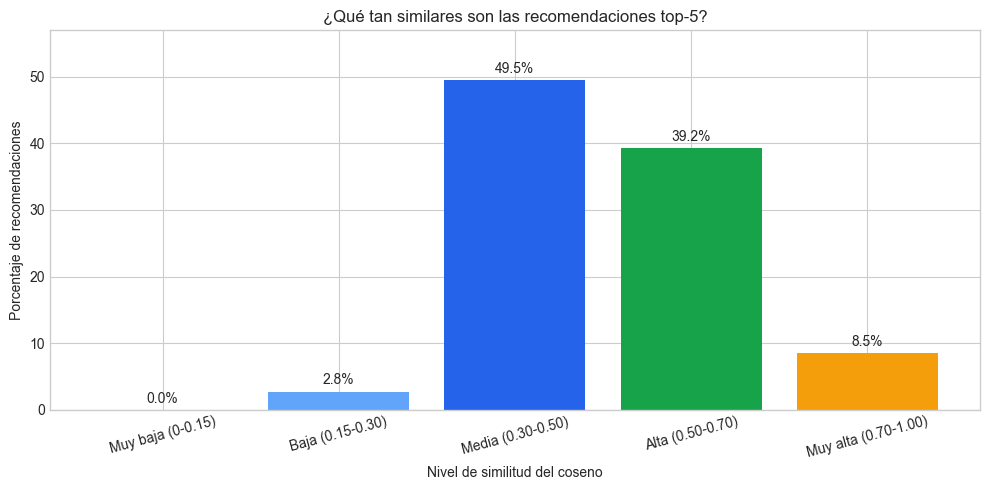

,rango_similitud,recomendaciones,porcentaje
0,Muy baja (0-0.15),0,0.00
1,Baja (0.15-0.30),22,2.75
2,Media (0.30-0.50),396,49.50
3,Alta (0.50-0.70),314,39.25
4,Muy alta (0.70-1.00),68,8.50


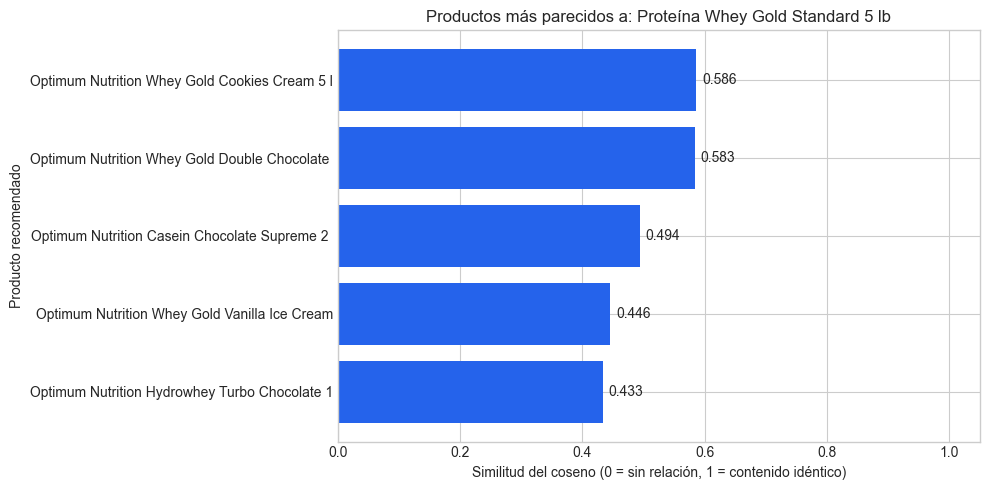

,Producto consultado,Producto recomendado,Categoría,Marca,Similitud
0,Proteína Whey Gold Standard 5 lb,Optimum Nutrition Whey Gold Cookies Cream 5 lb,Suplementos,Optimum Nutrition,0.586399
1,Proteína Whey Gold Standard 5 lb,Optimum Nutrition Whey Gold Double Chocolate 2 lb,Suplementos,Optimum Nutrition,0.583427
2,Proteína Whey Gold Standard 5 lb,Optimum Nutrition Casein Chocolate Supreme 2 lb,Suplementos,Optimum Nutrition,0.494176
3,Proteína Whey Gold Standard 5 lb,Optimum Nutrition Whey Gold Vanilla Ice Cream 2 lb,Suplementos,Optimum Nutrition,0.445752
4,Proteína Whey Gold Standard 5 lb,Optimum Nutrition Hydrowhey Turbo Chocolate 1.6 lb,Suplementos,Optimum Nutrition,0.432937


,Valor,Interpretación
0,0,Los textos de los productos no comparten términos relevantes.
1,Cercano a 0,Los productos comparten pocas características.
2,Cercano a 1,Los productos comparten muchas características de contenido.


In [28]:
rangos = pd.cut(
    scores_top5,
    bins=[-0.000001, 0.15, 0.30, 0.50, 0.70, 1.00],
    labels=[
        "Muy baja (0-0.15)",
        "Baja (0.15-0.30)",
        "Media (0.30-0.50)",
        "Alta (0.50-0.70)",
        "Muy alta (0.70-1.00)",
    ],
    include_lowest=True,
)

resumen_rangos = (
    pd.Series(rangos, name="rango_similitud")
    .value_counts(sort=False)
    .rename_axis("rango_similitud")
    .reset_index(name="recomendaciones")
)
resumen_rangos["porcentaje"] = (
    resumen_rangos["recomendaciones"] / resumen_rangos["recomendaciones"].sum() * 100
).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(
    resumen_rangos["rango_similitud"].astype(str),
    resumen_rangos["porcentaje"],
    color=["#94a3b8", "#60a5fa", "#2563eb", "#16a34a", "#f59e0b"],
)
ax.bar_label(barras, labels=[f"{valor:.1f}%" for valor in resumen_rangos["porcentaje"]], padding=3)
ax.set_title("¿Qué tan similares son las recomendaciones top-5?")
ax.set_xlabel("Nivel de similitud del coseno")
ax.set_ylabel("Porcentaje de recomendaciones")
ax.set_ylim(0, max(resumen_rangos["porcentaje"]) * 1.15)
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

display(resumen_rangos)

producto_base = df.loc[df["id_producto"] == ID_PRODUCTO_EJEMPLO, "producto"].iloc[0]
recomendaciones_grafica = recomendar_por_id(ID_PRODUCTO_EJEMPLO, top_n=5).copy()
recomendaciones_grafica["producto_corto"] = recomendaciones_grafica["producto"].str.slice(0, 45)
recomendaciones_ordenadas = recomendaciones_grafica.sort_values("score_similitud")

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(
    recomendaciones_ordenadas["producto_corto"],
    recomendaciones_ordenadas["score_similitud"],
    color="#2563eb",
)
ax.bar_label(barras, labels=[f"{valor:.3f}" for valor in recomendaciones_ordenadas["score_similitud"]], padding=4)
ax.set_title(f"Productos más parecidos a: {producto_base[:55]}")
ax.set_xlabel("Similitud del coseno (0 = sin relación, 1 = contenido idéntico)")
ax.set_ylabel("Producto recomendado")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

display(
    recomendaciones_grafica[["producto_base", "producto", "categoryName", "brandName", "score_similitud"]]
    .rename(columns={
        "producto_base": "Producto consultado",
        "producto": "Producto recomendado",
        "categoryName": "Categoría",
        "brandName": "Marca",
        "score_similitud": "Similitud",
    })
)

guia_lectura = pd.DataFrame([
    {"Valor": "0", "Interpretación": "Los textos de los productos no comparten términos relevantes."},
    {"Valor": "Cercano a 0", "Interpretación": "Los productos comparten pocas características."},
    {"Valor": "Cercano a 1", "Interpretación": "Los productos comparten muchas características de contenido."},
])
display(guia_lectura)


**Interpretación:** la primera gráfica analiza únicamente las recomendaciones top-5 generadas dentro de la misma categoría, por lo que representa el comportamiento real del recomendador y no combinaciones irrelevantes del catálogo completo. La segunda gráfica presenta un caso concreto: cuanto mayor es la barra, más atributos de contenido comparte el producto recomendado con el producto consultado. La puntuación expresa semejanza de contenido, no calidad ni popularidad.


## 6. Despliegue

En esta etapa se guardan los artefactos finales que permiten reutilizar el recomendador sin volver a ejecutar toda la libreta. Los artefactos exportados son:

1. `vectorizer.joblib`
2. `matriz_tfidf.npz`
3. `productos_recomendacion.json`
4. `metadata.json`


In [29]:
productos_exportar = df.drop(columns=["texto_modelo"]).to_dict(orient="records")

vectorizer_path = ARTIFACTS_DIR / "vectorizer.joblib"
matrix_path = ARTIFACTS_DIR / "matriz_tfidf.npz"
products_path = ARTIFACTS_DIR / "productos_recomendacion.json"
metadata_path = ARTIFACTS_DIR / "metadata.json"

joblib.dump(vectorizer, vectorizer_path)
save_npz(matrix_path, matriz_tfidf)
products_path.write_text(
    json.dumps(productos_exportar, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

metadata = {
    "solution": "Solución 1 - Recomendación de productos por similitud del coseno",
    "methodology": "CRISP-DM",
    "dataset": str(DATASET_PATH.name),
    "random_state": RANDOM_STATE,
    "products_count": int(len(df)),
    "columns_count": int(df.shape[1]),
    "terms_count": int(matriz_tfidf.shape[1]),
    "tfidf_shape": [int(matriz_tfidf.shape[0]), int(matriz_tfidf.shape[1])],
    "evaluation": metricas_evaluacion,
    "artifacts": {
        "vectorizer": str(vectorizer_path.name),
        "matrix": str(matrix_path.name),
        "products": str(products_path.name),
        "metadata": str(metadata_path.name),
    },
}
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

artefactos = pd.DataFrame([
    {"artefacto": path.name, "ruta": str(path), "tamano_bytes": path.stat().st_size}
    for path in [vectorizer_path, matrix_path, products_path, metadata_path]
])
display(artefactos)
display(pd.DataFrame(metadata.items(), columns=["campo", "valor"]))


,artefacto,ruta,tamano_bytes
0,vectorizer.joblib,C:\Users\castr\OneDrive\Escritorio\prueba\entrega_ecbd\solucion_1_recomendacion\artefa...,15738
1,matriz_tfidf.npz,C:\Users\castr\OneDrive\Escritorio\prueba\entrega_ecbd\solucion_1_recomendacion\artefa...,28958
2,productos_recomendacion.json,C:\Users\castr\OneDrive\Escritorio\prueba\entrega_ecbd\solucion_1_recomendacion\artefa...,107331
3,metadata.json,C:\Users\castr\OneDrive\Escritorio\prueba\entrega_ecbd\solucion_1_recomendacion\artefa...,835


,campo,valor
0,solution,Solución 1 - Recomendación de productos por similitud del coseno
1,methodology,CRISP-DM
2,dataset,recomendacion.csv
3,random_state,42
4,products_count,160
5,columns_count,16
6,terms_count,614
7,tfidf_shape,"[160, 614]"
8,evaluation,"{'productos_evaluados': 160, 'recomendaciones_top5_generadas': 800, 'similitud_minima_..."
9,artifacts,"{'vectorizer': 'vectorizer.joblib', 'matrix': 'matriz_tfidf.npz', 'products': 'product..."


## 7. Conclusión de la solución

La libreta permite reproducir el flujo completo de la primera solución: carga del dataset, control de calidad, preparación textual, vectorización TF-IDF, cálculo de similitud del coseno, evaluación funcional, gráficas de interpretación y exportación de artefactos.

El resultado es un recomendador basado en contenido que puede sugerir productos similares a partir de los atributos reales del catálogo de Titanium Sport Gym.
